<a href="https://colab.research.google.com/github/seifdabbous/deep-learning/blob/main/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_circles

In [2]:
n_samples = 1000

In [3]:
 x, y = make_circles(n_samples,noise= 0.03,random_state=42)

In [4]:
print(x[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [5]:
x[0]

array([0.75424625, 0.23148074])

In [6]:
y[:5]

array([1, 1, 1, 1, 0])

In [7]:
import pandas as pd

In [14]:
df = pd.DataFrame({"x1":x[:,0],"x2":x[:,1],"label":y})
print(circles)

           x1        x2  label
0    0.754246  0.231481      1
1   -0.756159  0.153259      1
2   -0.815392  0.173282      1
3   -0.393731  0.692883      1
4    0.442208 -0.896723      0
..        ...       ...    ...
995  0.244054  0.944125      0
996 -0.978655 -0.272373      0
997 -0.136900 -0.810012      1
998  0.670362 -0.767502      0
999  0.281057  0.963824      0

[1000 rows x 3 columns]


In [15]:
df.head()

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [16]:
df.label.value_counts()

,count
label,
1,500
0,500


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

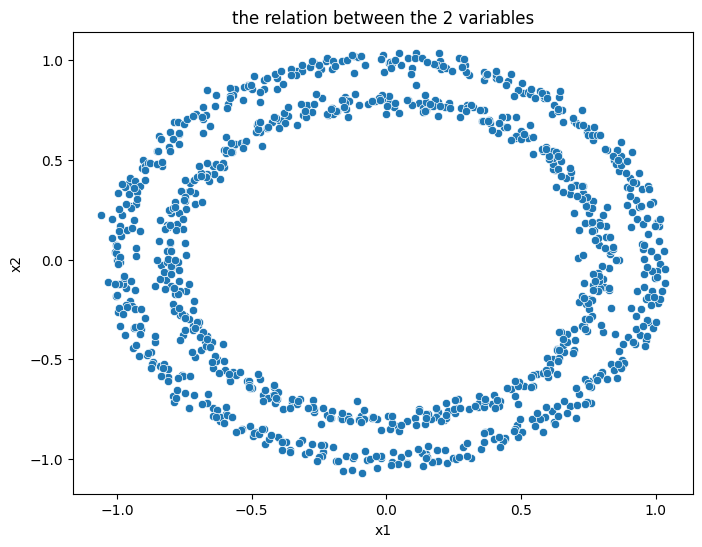

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x= "x1",y= "x2")
plt.title("the relation between the 2 variables")
plt.show()

In [19]:
import torch

In [ ]:
x = torch.from_numpy(x).type(torch.float)


In [27]:
x

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        ...,
        [-0.1369, -0.8100],
        [ 0.6704, -0.7675],
        [ 0.2811,  0.9638]])

In [29]:
y = torch.from_numpy(y).type(torch.float)

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)

In [33]:
from torch import nn

In [37]:
model0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
)

In [38]:
import torch

In [39]:
from sklearn.metrics import classification_report

In [41]:
model0.eval()

with torch.inference_mode():
    logits = model0(x_test)
    y_pred = torch.round(torch.sigmoid(logits))

In [42]:
print(classification_report(
    y_test.cpu().numpy(),
    y_pred.cpu().numpy()
))

              precision    recall  f1-score   support

         0.0       0.52      0.58      0.55       100
         1.0       0.52      0.46      0.49       100

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200

